In [ ]:
%matplotlib inline     
 ## wsl 환경에서 이미지 보이게 하기

In [1]:
## GPU 확인
import torch
## 단축키 안될때
## CTRL+SHIFT+P => developer : Reload window
print(f"PyTorch : {torch.__version__}")
print(f"CUDA 사용 : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch : 2.12.1+cu130
CUDA 사용 : True
GPU: NVIDIA GeForce RTX 3070


In [2]:
## 학습
from  ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data="cat_dog_tiger/data.yaml",
    epochs=100,
    imgsz=640,
    batch=4
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/lee/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.78 🚀 Python-3.12.3 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cat_dog_tiger/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x786bdc67dd00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /home/lee/aiprj/cat_dog_tiger/test/images/e91f74166cd7e74eafb168120127a628_jpg.rf.84fa05523d309ededf81502276dc762f.jpg: 640x640 1 tiger, 39.0ms
Speed: 3.1ms preprocess, 39.0ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)
tiger 0.799490213394165


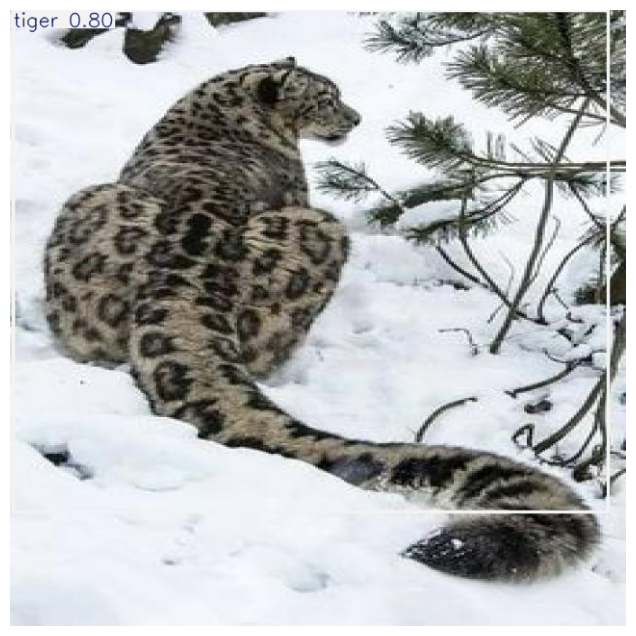

In [9]:
### 이미지 1장 탐지
import matplotlib.pyplot as plt

testImg = "cat_dog_tiger/test/images/e91f74166cd7e74eafb168120127a628_jpg.rf.84fa05523d309ededf81502276dc762f.jpg"

## 학습한 모델 가져오기
model=YOLO("runs/detect/train/weights/best.pt")

res = model(
    testImg,
    device=0
)

for r in res:
    for box in r.boxes:
        cls = int(box.cls[0])
        print(model.names[cls], float(box.conf[0]))

    im = r.plot()
    
    plt.figure(figsize=(10,8))
    plt.imshow(im[:,:,::-1])  #BGR->RGB
    plt.axis("off")
    plt.show()
        